In [2]:
import numpy as np  
from scipy import misc
import matplotlib.pyplot as plt

Recall that we can do operations (like multiplication) on arrays via [broadcasting](https://numpy.org/doc/stable/user/basics.broadcasting.html), in which we "stretch" one array so we can perform element-by-element multiplication.

In [28]:
array_a = np.array([[1, 0],[0,1]])
array_b = np.array([1,2])

In [31]:
array_a * array_b

array([[1, 0],
       [0, 2]])

In many advanced data science techniques, we use an operation called matrix multiplication - which is _not_ the same as the operation shown above!

In [32]:
np.matmul(array_a, array_b) 

array([1, 2])

Note that we can accomplish the same operation with the `@` operator:

In [33]:
array_a @ array_b

array([1, 2])

What did we do exactly? Let's write the arrays in mathematical notation and step through the calculation.

$\begin{bmatrix} 1 & 0 \\0 & 1 \end{bmatrix}$ * $\begin{bmatrix} 1 \\ 2  \end{bmatrix}$

## What can we use matrix multiplication for?
Matrix multiplication is used in so many types of computations- one of the most immediately rewarding is for transforming images. We can use matrix multiplication to rotate a picture, for example.

/var/folders/1d/58s_c4k94yz3p7h708cy7g880000gq/T/ipykernel_14600/2402196861.py:1: DeprecationWarning: scipy.misc.face has been deprecated in SciPy v1.10.0; and will be completely removed in SciPy v1.12.0. Dataset methods have moved into the scipy.datasets module. Use scipy.datasets.face instead.
  face = misc.face(gray=True)


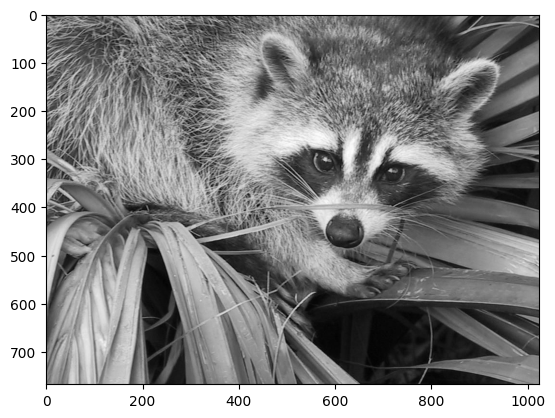

In [7]:
face = misc.face(gray=True)
plt.gray()
plt.imshow(face)

We define a _transformation matrix_.

In [8]:
transform = np.rot90(np.eye(1024))

And then we multiply our image matrix by the transformation matrix.

In [9]:
transformed_face = np.matmul(face, transform)

Let's plot the original and the result side-by-side.

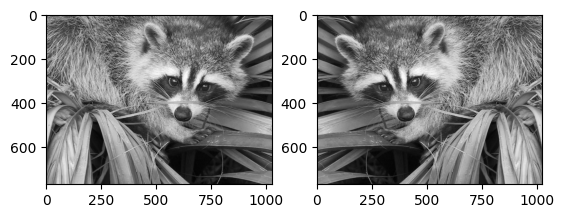

In [10]:
plt.subplot(1, 2, 1)
plt.imshow(face)
plt.subplot(1, 2, 2)
plt.imshow(transformed_face)

### How exactly did we transform this image?
Let's consider a much tinier example.

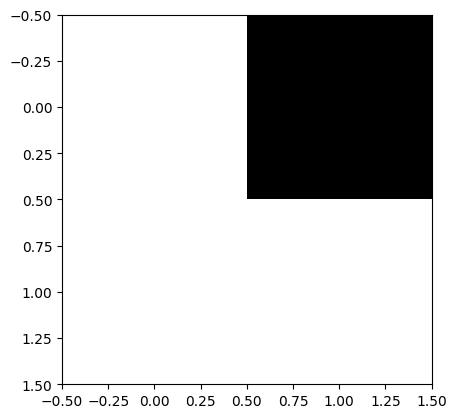

In [17]:
tiny_image = np.array([[1,0],[1,1]])
plt.imshow(tiny_image)


In [41]:
tiny_transform = np.rot90(np.eye(2))
tiny_transform

array([[0., 1.],
       [1., 0.]])

What is our matrix multiplication setup? 

$\begin{bmatrix} 1 & 0 \\1 & 1  \end{bmatrix}$ * $\begin{bmatrix} 0 & 1 \\1 & 0 \end{bmatrix}$

Let's try this by hand.

Then, let's run the computation and plot it.


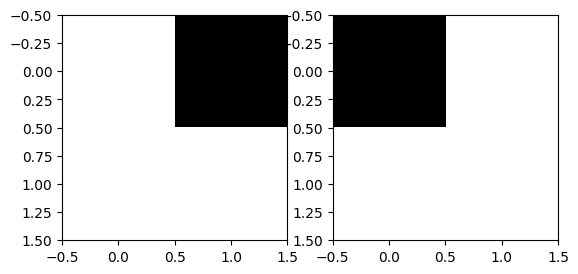

In [42]:
transformed_tiny_image = np.matmul(tiny_image, tiny_transform)

plt.subplot(1, 2, 1)
plt.imshow(tiny_image)
plt.subplot(1, 2, 2)
plt.imshow(transformed_tiny_image)

One way to think of matrix multiplication is as applying a _transformation_ to our data. When we multiply our image array by `transform`, we modify the image in a predictable way! 

Although you may rarely have to do matrix multiplication by hand, it is used "under the hood" in a huge variety of applications: 
- implementing neural networks 
- estimating a linear regression model
- dimensionality reduction techniques

## Matrix multiplication rules 
As is often the case, we have to be mindful about the properties of arrays we are operating on. 

In [43]:
array_c = np.ones((4, 4))
array_d = np.ones((10, 1))
array_e = np.ones((2,4))
array_f = np.ones((4, 1))

In [44]:
array_c @ array_d

ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 10 is different from 4)

In [45]:
array_c @ array_e

ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 2 is different from 4)

In [46]:
array_c @ array_f

array([[4.],
       [4.],
       [4.],
       [4.]])